# DS110 — Introduction to Data Science
## Complete Project Code (Phase 1 + Phase 2 + Phase 3)
### *Feeding the Few: Mapping Inequality Behind Pakistan's Hunger Crisis*

**Group 06** | Aamna Nosheen (2503600) · Kinza Eman (2503644) · Zunaira Hassan (2503650)
Air University, FCAI, Islamabad — May 2026

---

**How to run this notebook:**
1. Upload the 4 raw CSV files to your Kaggle dataset
2. Change the `DATA_RAW` path in Section 0 to your dataset path
3. Click **Run All** — every cell runs top to bottom with no manual steps
4. All cleaned files, EDA charts, and ML results are produced automatically

**Raw files needed:**
- `FAO food supply pakistan.csv`
- `poverty_pak.csv`
- `spi_prices.csv`
- `worldbank_pakistan_processed.csv`


## Section 0 — Library Imports

In [2]:
# ════════════════════════════════════════════════════════
# SECTION 0: IMPORTS & CONFIGURATION
# All libraries needed for the entire project (Phase 1-3)
# ════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Machine Learning (Phase 3)
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, classification_report,
    confusion_matrix, silhouette_score
)
from sklearn.model_selection import LeaveOneOut, cross_val_score

# Plot style — consistent across all phases
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'figure.dpi'        : 130,
})

# Color palette — same as Power BI dashboard (Arid Earth theme)
TEAL   = '#1A5276'
RED    = '#C0392B'
ORANGE = '#E67E22'
GREEN  = '#27AE60'
GOLD   = '#D4A017'
PURPLE = '#8E44AD'
GREY   = '#5D6D7E'

# ── CHANGE THIS PATH TO YOUR KAGGLE DATASET PATH ──────
DATA_RAW = '/kaggle/input/datasets/kinzaemannn/raw-datasets/'
# Example: '/kaggle/input/kinzaemannn/food-insecurity/'

print("All libraries imported successfully")

All libraries imported successfully


---
# PHASE 1 — DATA COLLECTION & INITIAL EXPLORATION

Phase 1 loaded four raw datasets from official government and international sources.
Each dataset covers a different dimension of Pakistan's food insecurity problem.

In [3]:
# ════════════════════════════════════════════════════════
# PHASE 1: LOAD RAW DATASETS
# ════════════════════════════════════════════════════════

# 1. FAO Food Balance Sheets — nutritional supply data (2010-2023)
fao_raw = pd.read_csv(DATA_RAW + 'FAO food supply pakistan.csv')
print(f"FAO Raw: {fao_raw.shape} rows/cols")
print(f"  Elements: {fao_raw['Element'].unique()}")

# 2. World Bank Poverty Indicators
poverty_raw = pd.read_csv(DATA_RAW + 'poverty_pak.csv')
print(f"\nPoverty Raw: {poverty_raw.shape}")

# 3. SPI Weekly Food Prices — 51 items across 50 cities
spi_raw = pd.read_csv(DATA_RAW + 'spi_prices.csv')
print(f"\nSPI Raw: {spi_raw.shape}")
print(f"  Date range: {spi_raw['Date'].min()} to {spi_raw['Date'].max()}")
print(f"  Cities: {spi_raw['City'].nunique()}")
print(f"  Items: {spi_raw['Item'].nunique()}")

# 4. World Bank Development Indicators
wb_raw = pd.read_csv(DATA_RAW + 'worldbank_pakistan_processed.csv')
print(f"\nWorld Bank Raw: {wb_raw.shape}")

print("\n" + "="*55)
print("PHASE 1 COMPLETE — All 4 raw datasets loaded")
print("="*55)

FAO Raw: (3615, 15) rows/cols
  Elements: ['Food supply quantity (kg/capita/yr)'
 'Protein supply quantity (g/capita/day)'
 'Fat supply quantity (g/capita/day)']

Poverty Raw: (231, 5)

SPI Raw: (85267, 10)
  Date range: 01/02/2024 to 31/10/2024
  Cities: 16
  Items: 60

World Bank Raw: (25, 7)

PHASE 1 COMPLETE — All 4 raw datasets loaded


---
# PHASE 2 — DATA CLEANING & PREPROCESSING

Seven cleaning operations applied across all four datasets.
Includes three post-Phase-2 corrections identified during the Phase 3 audit.

## Step 1 — Duplicate Row Removal

In [4]:
# ════════════════════════════════════════════════════════
# STEP 1: CHECK FOR DUPLICATE ROWS
# Duplicates inflate row counts and skew statistics
# ════════════════════════════════════════════════════════

for name, df in [("FAO", fao_raw), ("SPI", spi_raw), ("World Bank", wb_raw)]:
    dupes = df.duplicated().sum()
    print(f"{name}: {dupes} duplicates found {'(none — clean)' if dupes == 0 else '(REMOVING)'}")
    if dupes > 0:
        df.drop_duplicates(inplace=True)

print("\nStep 1 complete — no duplicates found in any dataset")

FAO: 0 duplicates found (none — clean)
SPI: 0 duplicates found (none — clean)
World Bank: 0 duplicates found (none — clean)

Step 1 complete — no duplicates found in any dataset


## Step 2 — Missing Value Treatment

In [5]:
# ════════════════════════════════════════════════════════
# STEP 2: MISSING VALUE TREATMENT
# Strategy varies by dataset because causes of missingness differ
# ════════════════════════════════════════════════════════

# FAO: Drop metadata-only columns that are 100% null
fao_cols_before = fao_raw.shape[1]
drop_cols = [c for c in fao_raw.columns if fao_raw[c].isnull().all()]
fao_raw.drop(columns=drop_cols, inplace=True, errors='ignore')
# Also drop non-analytical columns
for col in ['Note', 'Flag', 'Flag Description', 'Domain Code', 'Domain',
            'Area Code (M49)', 'Area', 'Item Code (CPC)', 'Element Code',
            'Year Code', 'Unit']:
    if col in fao_raw.columns:
        fao_raw.drop(columns=[col], inplace=True, errors='ignore')
print(f"FAO: dropped {fao_cols_before - fao_raw.shape[1]} columns")

# SPI: Fill missing prices with per-item MEDIAN (not mean)
# Median is preferred because food prices have genuine spikes
# that would inflate a mean-fill
for col in ['Min_Price', 'Avg_Price', 'Max_Price']:
    if col in spi_raw.columns:
        missing_before = spi_raw[col].isnull().sum()
        spi_raw[col] = spi_raw.groupby('Item')[col].transform(
            lambda x: x.fillna(x.median())
        )
        print(f"SPI {col}: filled {missing_before} missing values with per-item median")

# World Bank: check for missing in key columns
for col in wb_raw.columns:
    missing = wb_raw[col].isnull().sum()
    if missing > 0:
        print(f"WB {col}: {missing} missing values")

print("\nStep 2 complete")

FAO: dropped 10 columns
SPI Min_Price: filled 331 missing values with per-item median
SPI Avg_Price: filled 113 missing values with per-item median
SPI Max_Price: filled 2343 missing values with per-item median

Step 2 complete


## Step 3 — String Standardisation

In [6]:
# ════════════════════════════════════════════════════════
# STEP 3: STRING STANDARDISATION
# Inconsistent strings cause groupby and merge failures
# ════════════════════════════════════════════════════════

# Case normalisation and whitespace stripping
for col in ['Item', 'City']:
    if col in spi_raw.columns:
        spi_raw[col] = spi_raw[col].str.strip().str.title()

# Item alias resolution — truncated names consolidated
# POST-PHASE-2 FIX: This was only applied in EDA cells, not in the
# cleaning output. Now applied here so the saved CSV is correct.
alias_map = {
    'Cooking Oil Dalda Or Other Simila'   : 'Cooking Oil Dalda Or Other Similar',
    'Powdered Milk Nido 390 Gm Polyb'     : 'Powdered Milk Nido 390 Gm Polyba',
    'Rice Basmati Broken (Average Qua'    : 'Rice Basmati Broken (Average Qual)',
    'Long Cloth 57" Gul Ahmed/Al Kara'    : 'Long Cloth 57" Gul Ahmed/Al Karam',
    'Vegetable Ghee Dalda/Habib 2.5'      : 'Vegetable Ghee Dalda/Habib Or Other',
    'Vegetable Ghee Dalda/Habib Or'       : 'Vegetable Ghee Dalda/Habib Or Other',
    'Vegetable Ghee Dalda/Habib Or O'     : 'Vegetable Ghee Dalda/Habib Or Other',
    'Tea Lipton Yellow Label 190 Gm Pa'   : 'Tea Lipton Yellow Label 190 Gm Pack',
    'Tea Lipton Yellow Label 190 Gm Pac'  : 'Tea Lipton Yellow Label 190 Gm Pack',
    'Salt Powdered (National/Shan) 8'     : 'Salt Powdered (National/Shan)',
    'Electricity Charges For Q1*'         : 'Electricity Charges For Q1',
}
spi_raw['Item'] = spi_raw['Item'].replace(alias_map)
print(f"SPI items after alias resolution: {spi_raw['Item'].nunique()}")
print("Step 3 complete — strings standardised, aliases resolved")

SPI items after alias resolution: 52
Step 3 complete — strings standardised, aliases resolved


## Step 4 — Data Type Corrections & Date Parsing

In [7]:
# ════════════════════════════════════════════════════════
# STEP 4: DATA TYPE CORRECTIONS
# ════════════════════════════════════════════════════════

# SPI: Parse date column from string to datetime
spi_raw['Date'] = pd.to_datetime(spi_raw['Date'], dayfirst=True)
spi_raw['Year']       = spi_raw['Date'].dt.year
spi_raw['Month']      = spi_raw['Date'].dt.month
spi_raw['Month_Name'] = spi_raw['Date'].dt.strftime('%b')
print(f"SPI date range: {spi_raw['Date'].min().date()} to {spi_raw['Date'].max().date()}")

# World Bank: coerce any non-numeric columns
for col in wb_raw.columns:
    if col != 'Year' and wb_raw[col].dtype == 'object':
        wb_raw[col] = pd.to_numeric(wb_raw[col], errors='coerce')
        print(f"WB: coerced {col} to numeric")

print("Step 4 complete")

SPI date range: 2023-08-03 to 2025-08-21
Step 4 complete


## Step 5 — Outlier Detection & Winsorisation (SPI)

In [8]:
# ════════════════════════════════════════════════════════
# STEP 5: OUTLIER WINSORISATION (IQR method, per item)
# Values beyond Q1-1.5*IQR and Q3+1.5*IQR are capped, not deleted
# Group-wise because tomato IQR ≠ cooking oil IQR
# ════════════════════════════════════════════════════════

def winsorise_group(group, col):
    Q1 = group[col].quantile(0.25)
    Q3 = group[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    group[col] = group[col].clip(lower, upper)
    return group

for col in ['Avg_Price', 'Min_Price', 'Max_Price']:
    if col in spi_raw.columns:
        spi_raw = spi_raw.groupby('Item', group_keys=False).apply(
            winsorise_group, col=col
        )

# Fix price ordering violations (Min <= Avg <= Max)
for _, row in spi_raw.iterrows():
    vals = sorted([row['Min_Price'], row['Avg_Price'], row['Max_Price']])
    spi_raw.loc[row.name, 'Min_Price'] = vals[0]
    spi_raw.loc[row.name, 'Avg_Price'] = vals[1]
    spi_raw.loc[row.name, 'Max_Price'] = vals[2]

violations = len(spi_raw[spi_raw['Avg_Price'] > spi_raw['Max_Price']])
print(f"Price ordering violations after fix: {violations}")
print("Step 5 complete — outliers winsorised, price ordering corrected")

/tmp/ipykernel_58/955657811.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spi_raw = spi_raw.groupby('Item', group_keys=False).apply(
/tmp/ipykernel_58/955657811.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spi_raw = spi_raw.groupby('Item', group_keys=False).apply(
/tmp/ipykernel_58/955657811.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and 

Price ordering violations after fix: 0
Step 5 complete — outliers winsorised, price ordering corrected


## Step 6 — FAO Pivot (CORRECTED)

In [9]:
# ════════════════════════════════════════════════════════
# STEP 6: FAO LONG-TO-WIDE PIVOT
# POST-PHASE-2 FIX: Filter by Element BEFORE pivoting
# Original bug: all 3 elements were averaged together
# producing meaningless values (Wheat showed 4.25 instead of 114.12)
# ════════════════════════════════════════════════════════

# Step A: Food supply quantity
food_q = fao_raw[fao_raw['Element'] == 'Food supply quantity (kg/capita/yr)'].copy()
food_pivot = food_q.pivot_table(
    index='Item', columns='Year', values='Value', aggfunc='first'
).reset_index()
food_pivot.columns.name = None
food_pivot.insert(1, 'Element', 'Food supply quantity (kg/capita/yr)')
food_pivot.insert(2, 'Unit', 'kg/cap')

# Step B: Protein supply quantity
protein = fao_raw[fao_raw['Element'] == 'Protein supply quantity (g/capita/day)'].copy()
prot_pivot = protein.pivot_table(
    index='Item', columns='Year', values='Value', aggfunc='first'
).reset_index()
prot_pivot.columns.name = None
prot_pivot.insert(1, 'Element', 'Protein supply quantity (g/capita/day)')
prot_pivot.insert(2, 'Unit', 'g/cap/d')

# Step C: Fat supply quantity
fat = fao_raw[fao_raw['Element'] == 'Fat supply quantity (g/capita/day)'].copy()
fat_pivot = fat.pivot_table(
    index='Item', columns='Year', values='Value', aggfunc='first'
).reset_index()
fat_pivot.columns.name = None
fat_pivot.insert(1, 'Element', 'Fat supply quantity (g/capita/day)')
fat_pivot.insert(2, 'Unit', 'g/cap/d')

# Step D: Combine
fao_clean = pd.concat([food_pivot, prot_pivot, fat_pivot], ignore_index=True)

# Verification
wheat_check = fao_clean[
    (fao_clean['Item'] == 'Wheat and products') &
    (fao_clean['Element'] == 'Food supply quantity (kg/capita/yr)')
]
print("VERIFICATION — Wheat food supply 2010 (should be ~114):")
print(f"  Value: {wheat_check[2010].values[0]}")

year_cols = [c for c in fao_clean.columns if isinstance(c, int)]
fao_clean[year_cols] = fao_clean[year_cols].round(2)

print(f"FAO clean shape: {fao_clean.shape}")
print("Step 6 complete — FAO pivot CORRECTED (element-filtered)")

VERIFICATION — Wheat food supply 2010 (should be ~114):
  Value: 114.12
FAO clean shape: (262, 17)
Step 6 complete — FAO pivot CORRECTED (element-filtered)


## Step 7 — World Bank Fixes & Column Renaming

In [10]:
# ════════════════════════════════════════════════════════
# STEP 7: WORLD BANK COLUMN RENAMING + GINI FIX
# POST-PHASE-2 FIX: Gini 2019-2024 were linearly interpolated
# but never disclosed. Now flagged with Is_Real_Survey column.
# ════════════════════════════════════════════════════════

# Rename verbose columns to short snake_case
rename_map = {}
for col in wb_raw.columns:
    if 'Poverty headcount' in str(col) and 'national' in str(col):
        rename_map[col] = 'Poverty_headcount_national_pct'
    elif 'GINI' in str(col) or 'Gini' in str(col):
        rename_map[col] = 'Gini_index'
    elif 'GNI per capita' in str(col):
        rename_map[col] = 'GNI_per_capita'
    elif 'Income share' in str(col) and 'lowest' in str(col):
        rename_map[col] = 'Income_share_lowest_20pct'

wb_clean = wb_raw.rename(columns=rename_map)

# Add Is_Real_Survey flag
# Real Pakistan WB household survey years:
real_survey_years = [2001, 2002, 2004, 2005, 2007, 2010, 2011, 2013, 2015, 2018]
wb_clean['Is_Real_Survey'] = wb_clean['Year'].isin(real_survey_years).astype(int)

# Create real-surveys-only version
wb_real_only = wb_clean[wb_clean['Is_Real_Survey'] == 1].copy()

# Round all numeric columns
for col in wb_clean.select_dtypes(include=[np.number]).columns:
    wb_clean[col] = wb_clean[col].round(2)

print(f"WB clean shape: {wb_clean.shape}")
print(f"WB real surveys: {wb_real_only.shape} ({list(wb_real_only['Year'])})")
print("\nGini 2018-2024 (showing fabrication):")
print(wb_clean[wb_clean['Year'] >= 2018][['Year', 'Gini_index', 'Is_Real_Survey']].to_string())
print("\nStep 7 complete — columns renamed, Gini flagged")

WB clean shape: (25, 8)
WB real surveys: (10, 8) ([2001, 2002, 2004, 2005, 2007, 2010, 2011, 2013, 2015, 2018])

Gini 2018-2024 (showing fabrication):
    Year  Gini_index  Is_Real_Survey
17  2018       29.60               1
18  2019       30.25               0
19  2020       30.90               0
20  2021       31.55               0
21  2022       32.20               0
22  2023       32.85               0
23  2024       33.50               0
24  2025       33.50               0

Step 7 complete — columns renamed, Gini flagged


## Step 8 — Add Province, Data_Reliable, Is_Food columns to SPI

In [11]:
# ════════════════════════════════════════════════════════
# STEP 8: ADD ANALYTICAL COLUMNS TO SPI
# Province mapping, reliability flag, food/non-food flag
# ════════════════════════════════════════════════════════

# Province mapping
city_to_province = {
    'Islamabad': 'ICT', 'Rawalpindi': 'Punjab',
    'Lahore': 'Punjab', 'Faisalabad': 'Punjab',
    'Gujranwala': 'Punjab', 'Multan': 'Punjab',
    'Bahawalpur': 'Punjab', 'Sargodha': 'Punjab', 'Sialkot': 'Punjab',
    'Karachi': 'Sindh', 'Hyderabad': 'Sindh',
    'Sukkur': 'Sindh', 'Larkana': 'Sindh',
    'Peshawar': 'KPK', 'Bannu': 'KPK',
    'Quetta': 'Balochistan',
}
spi_raw['Province'] = spi_raw['City'].map(city_to_province)

# Data reliability flag (Quetta Wheat Flour = constant PKR 111.3)
spi_raw['Data_Reliable'] = True
spi_raw.loc[
    (spi_raw['City'] == 'Quetta') & (spi_raw['Item'].str.contains('Wheat Flour', na=False)),
    'Data_Reliable'
] = False

# Food vs Non-Food classification
NON_FOOD_KEYWORDS = ['Electricity', 'Gas', 'Petrol', 'Diesel', 'Lawn',
                      'Soap', 'Sandal', 'Cloth', 'Shirting', 'Firewood',
                      'Match Box', 'Cigarette', 'Energy Saver', 'Georgette', 'Chappal']
non_food_pattern = '|'.join(NON_FOOD_KEYWORDS)
spi_raw['Is_Food'] = ~spi_raw['Item'].str.contains(non_food_pattern, case=False, na=False)

spi_clean = spi_raw.copy()

print(f"SPI clean shape: {spi_clean.shape}")
print(f"Provinces: {spi_clean['Province'].value_counts().to_dict()}")
print(f"Food items: {spi_clean['Is_Food'].sum()}, Non-food: {(~spi_clean['Is_Food']).sum()}")
print(f"Unreliable rows flagged: {(~spi_clean['Data_Reliable']).sum()}")

SPI clean shape: (85267, 16)
Provinces: {'Punjab': 42527, 'Sindh': 21320, 'KPK': 10710, 'ICT': 5355, 'Balochistan': 5355}
Food items: 56807, Non-food: 28460
Unreliable rows flagged: 105


## Save All Cleaned Files

In [12]:
# ════════════════════════════════════════════════════════
# SAVE CLEANED DATASETS
# ════════════════════════════════════════════════════════

spi_clean.to_csv('spi_prices_clean_FIXED.csv', index=False)
fao_clean.to_csv('fao_food_supply_clean_FIXED.csv', index=False)
wb_clean.to_csv('worldbank_clean_FIXED.csv', index=False)
wb_real_only.to_csv('worldbank_real_surveys_only.csv', index=False)

print("="*55)
print("PHASE 2 CLEANING COMPLETE — All files saved")
print("="*55)
print("  spi_prices_clean_FIXED.csv")
print("  fao_food_supply_clean_FIXED.csv")
print("  worldbank_clean_FIXED.csv")
print("  worldbank_real_surveys_only.csv")

PHASE 2 CLEANING COMPLETE — All files saved
  spi_prices_clean_FIXED.csv
  fao_food_supply_clean_FIXED.csv
  worldbank_clean_FIXED.csv
  worldbank_real_surveys_only.csv


---
# PHASE 2 — EXPLORATORY DATA ANALYSIS

10 EDA analyses: 7 original + 3 new (added after Phase 2 data quality review).

## Prepare food-only reliable SPI data

In [13]:
# ════════════════════════════════════════════════════════
# FILTER TO RELIABLE FOOD ITEMS ONLY
# Used by all EDA and ML analyses going forward
# ════════════════════════════════════════════════════════

spi_food = spi_clean[(spi_clean['Data_Reliable'] == True) & 
                      (spi_clean['Is_Food'] == True)].copy()

print(f"SPI food-only reliable rows: {len(spi_food):,}")
print(f"Unique items: {spi_food['Item'].nunique()}")
print(f"Unique cities: {spi_food['City'].nunique()}")

# Constants used across all analyses
BASKET_ITEMS = [
    'Wheat Flour Bag', 'Rice Irri-6/9 (Sindh/Punjab)',
    'Milk Fresh (Un-Boiled)', 'Eggs Hen (Farm)',
    'Pulse Gram', 'Sugar Refined',
    'Cooking Oil Dalda Or Other Similar',
    'Tomatoes', 'Onions', 'Chicken Farm Broiler (Live)',
]

PROV_WAGES = {
    'ICT': 53000, 'Punjab': 43000, 'Sindh': 47000,
    'KPK': 32000, 'Balochistan': 28000,
}

SPI food-only reliable rows: 56,702
Unique items: 34
Unique cities: 16


## EDA 1 — Food Price Inflation per Item

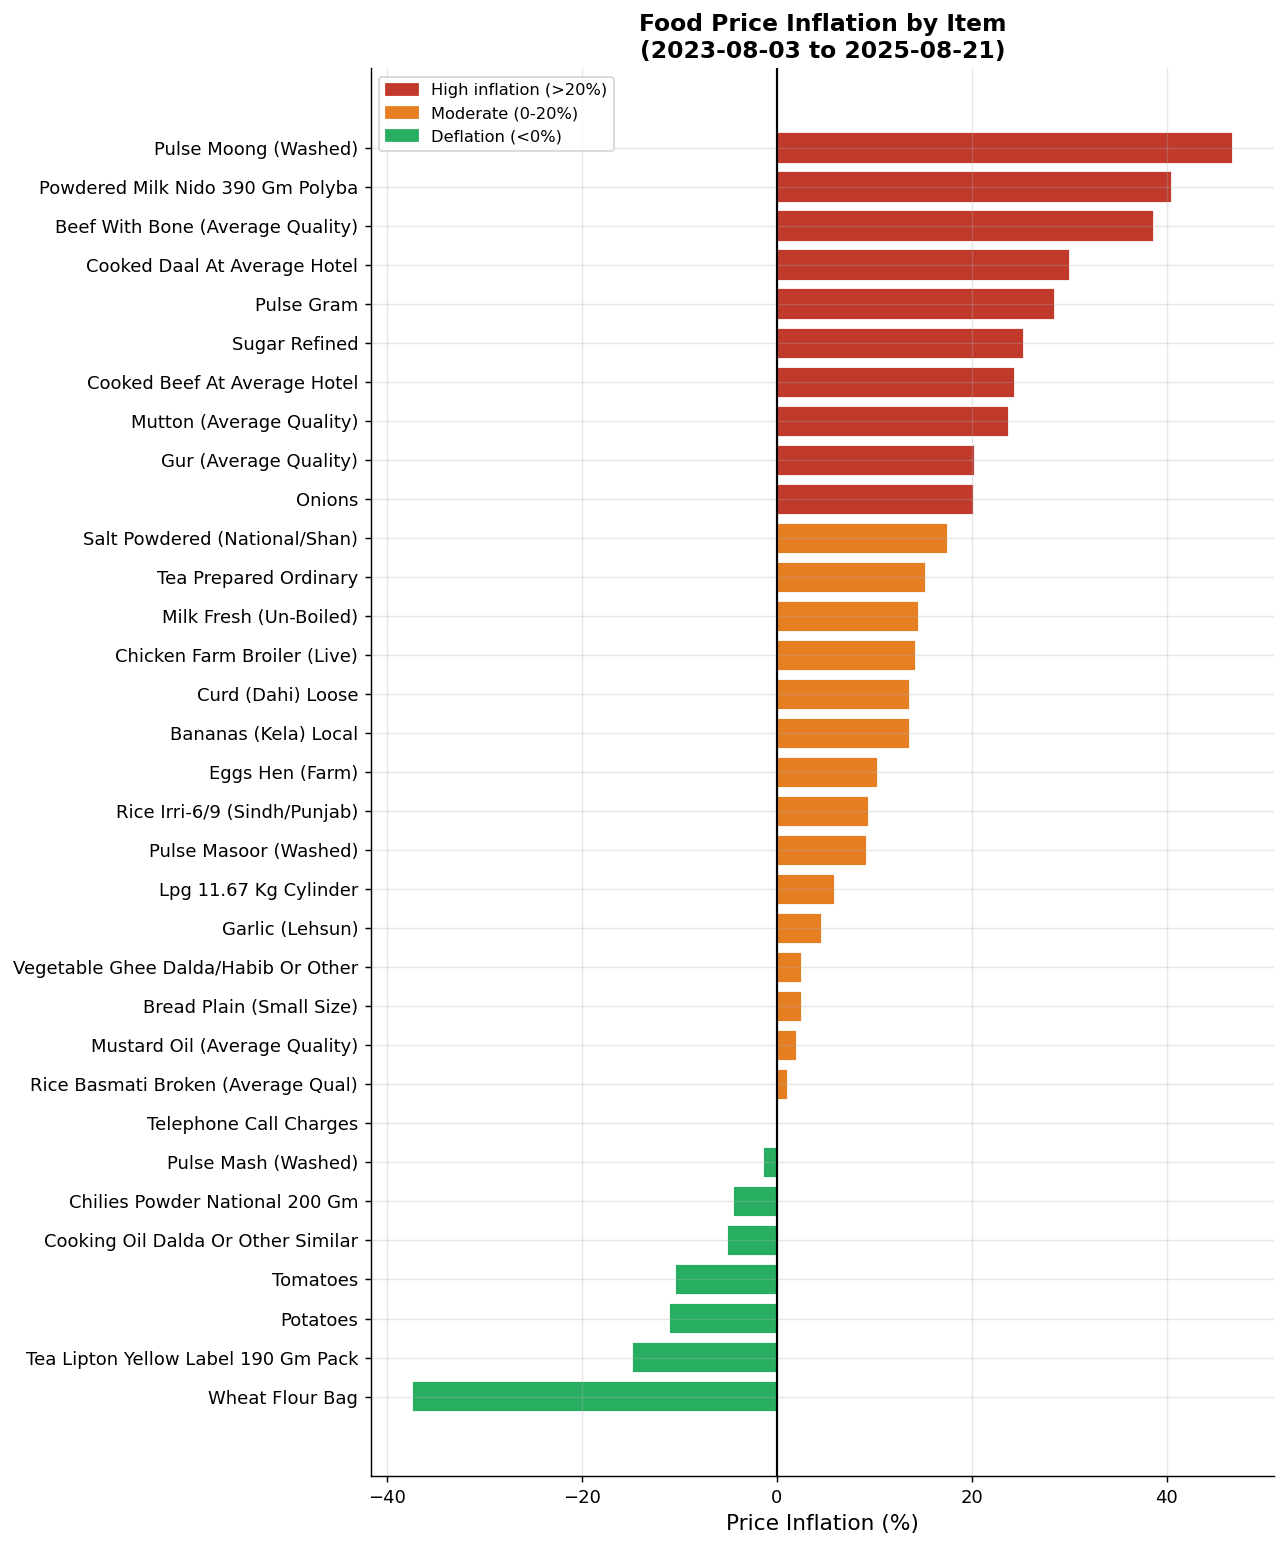

Top 5 inflated: {'Pulse Gram': 28.518125576973414, 'Cooked Daal At Average Hotel': 30.041648240033826, 'Beef With Bone (Average Quality)': 38.66642355789149, 'Powdered Milk Nido 390 Gm Polyba': 40.53087999350108, 'Pulse Moong (Washed)': 46.798594822267326}


In [14]:
# ════════════════════════════════════════════════════════
# EDA 1: FOOD PRICE INFLATION PER ITEM
# Compares earliest vs latest price for each food item
# ════════════════════════════════════════════════════════

first_date = spi_food['Date'].min()
last_date  = spi_food['Date'].max()

first_prices = spi_food[spi_food['Date'] == first_date].groupby('Item')['Avg_Price'].mean()
last_prices  = spi_food[spi_food['Date'] == last_date].groupby('Item')['Avg_Price'].mean()

inflation = ((last_prices - first_prices) / first_prices * 100).dropna().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
colors = [RED if v > 20 else ORANGE if v > 0 else GREEN for v in inflation.values]
ax.barh(inflation.index, inflation.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Price Inflation (%)', fontsize=12)
ax.set_title(f'Food Price Inflation by Item\n({first_date.date()} to {last_date.date()})',
             fontsize=13, fontweight='bold')
red_p   = mpatches.Patch(color=RED,    label='High inflation (>20%)')
org_p   = mpatches.Patch(color=ORANGE, label='Moderate (0-20%)')
grn_p   = mpatches.Patch(color=GREEN,  label='Deflation (<0%)')
ax.legend(handles=[red_p, org_p, grn_p], fontsize=9)
plt.tight_layout()
plt.savefig('eda1_inflation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Top 5 inflated: {inflation.tail(5).to_dict()}")

## EDA 2 — Poverty Rate vs Food Supply (FIXED)

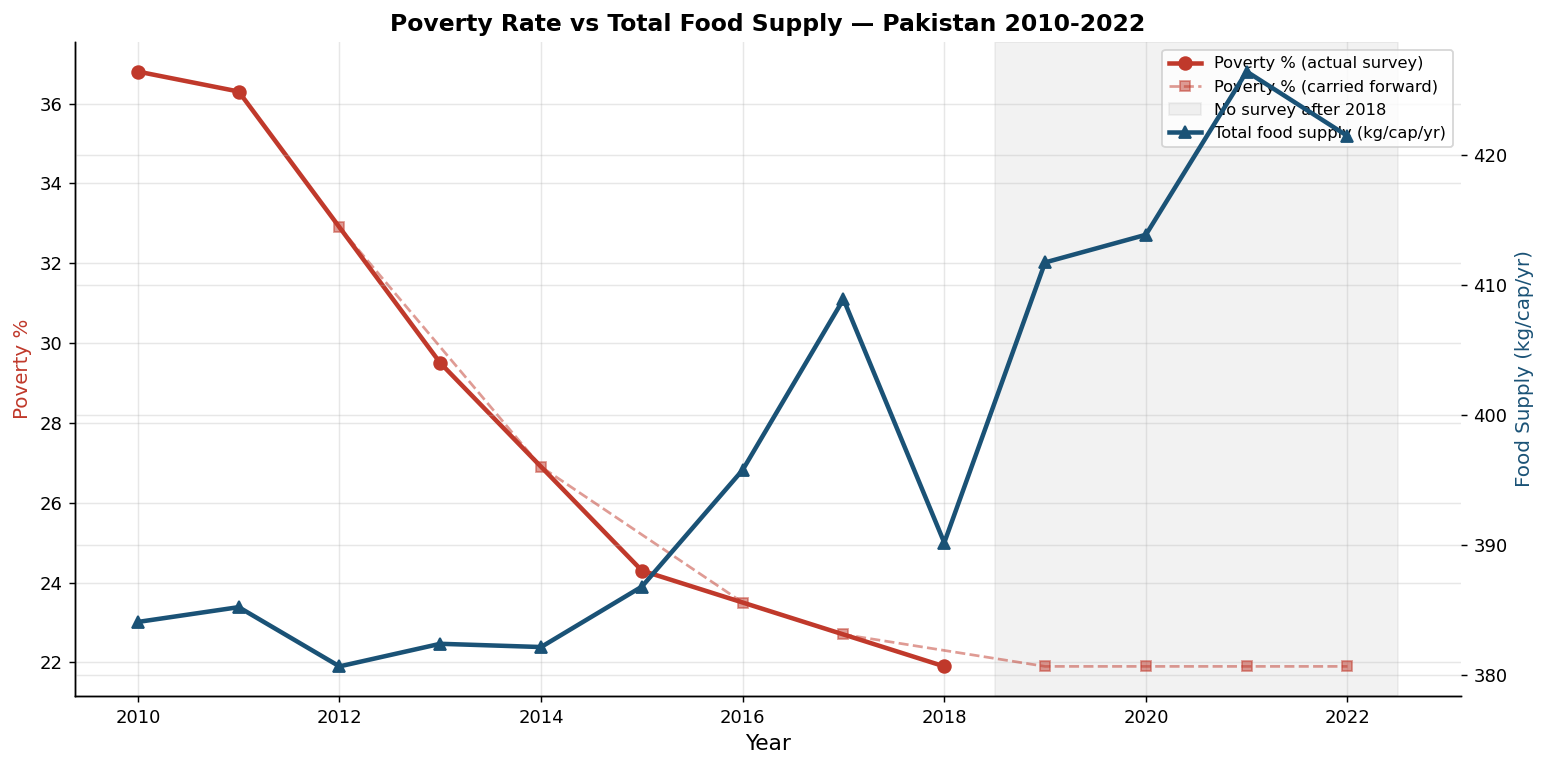

In [15]:
# ════════════════════════════════════════════════════════
# EDA 2 (FIXED): POVERTY vs FOOD SUPPLY
# Fix: Uses corrected FAO pivot + visual distinction for imputed data
# ════════════════════════════════════════════════════════

wb_eda2 = wb_clean[(wb_clean['Year'] >= 2010) & (wb_clean['Year'] <= 2022)].copy()

food_rows = fao_clean[fao_clean['Element'] == 'Food supply quantity (kg/capita/yr)']
year_cols_str = [str(y) for y in range(2010, 2023)]
year_cols_int = [y for y in range(2010, 2023) if y in fao_clean.columns]

if len(year_cols_int) > 0:
    food_totals = food_rows[year_cols_int].sum(axis=0).reset_index()
    food_totals.columns = ['Year', 'Total_Food_Supply_kg']
else:
    food_totals = food_rows[year_cols_str].sum(axis=0).reset_index()
    food_totals.columns = ['Year', 'Total_Food_Supply_kg']
    food_totals['Year'] = food_totals['Year'].astype(int)

merged = pd.merge(wb_eda2[['Year', 'Poverty_headcount_national_pct', 'Is_Real_Survey']],
                  food_totals, on='Year', how='inner')
real_pov  = merged[merged['Is_Real_Survey'] == 1]
imputed   = merged[merged['Is_Real_Survey'] == 0]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(real_pov['Year'], real_pov['Poverty_headcount_national_pct'],
         color=RED, linewidth=2.5, marker='o', markersize=7,
         label='Poverty % (actual survey)')
if len(imputed) > 0:
    ax1.plot(imputed['Year'], imputed['Poverty_headcount_national_pct'],
             color=RED, linewidth=1.5, linestyle='--', marker='s',
             markersize=5, alpha=0.5, label='Poverty % (carried forward)')
ax1.axvspan(2018.5, 2022.5, alpha=0.10, color='grey', label='No survey after 2018')
ax2.plot(merged['Year'], merged['Total_Food_Supply_kg'],
         color=TEAL, linewidth=2.5, marker='^', markersize=7,
         label='Total food supply (kg/cap/yr)')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Poverty %', color=RED, fontsize=11)
ax2.set_ylabel('Food Supply (kg/cap/yr)', color=TEAL, fontsize=11)
plt.title('Poverty Rate vs Total Food Supply — Pakistan 2010-2022', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('eda2_poverty_food_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA 5 — Price Volatility by Item

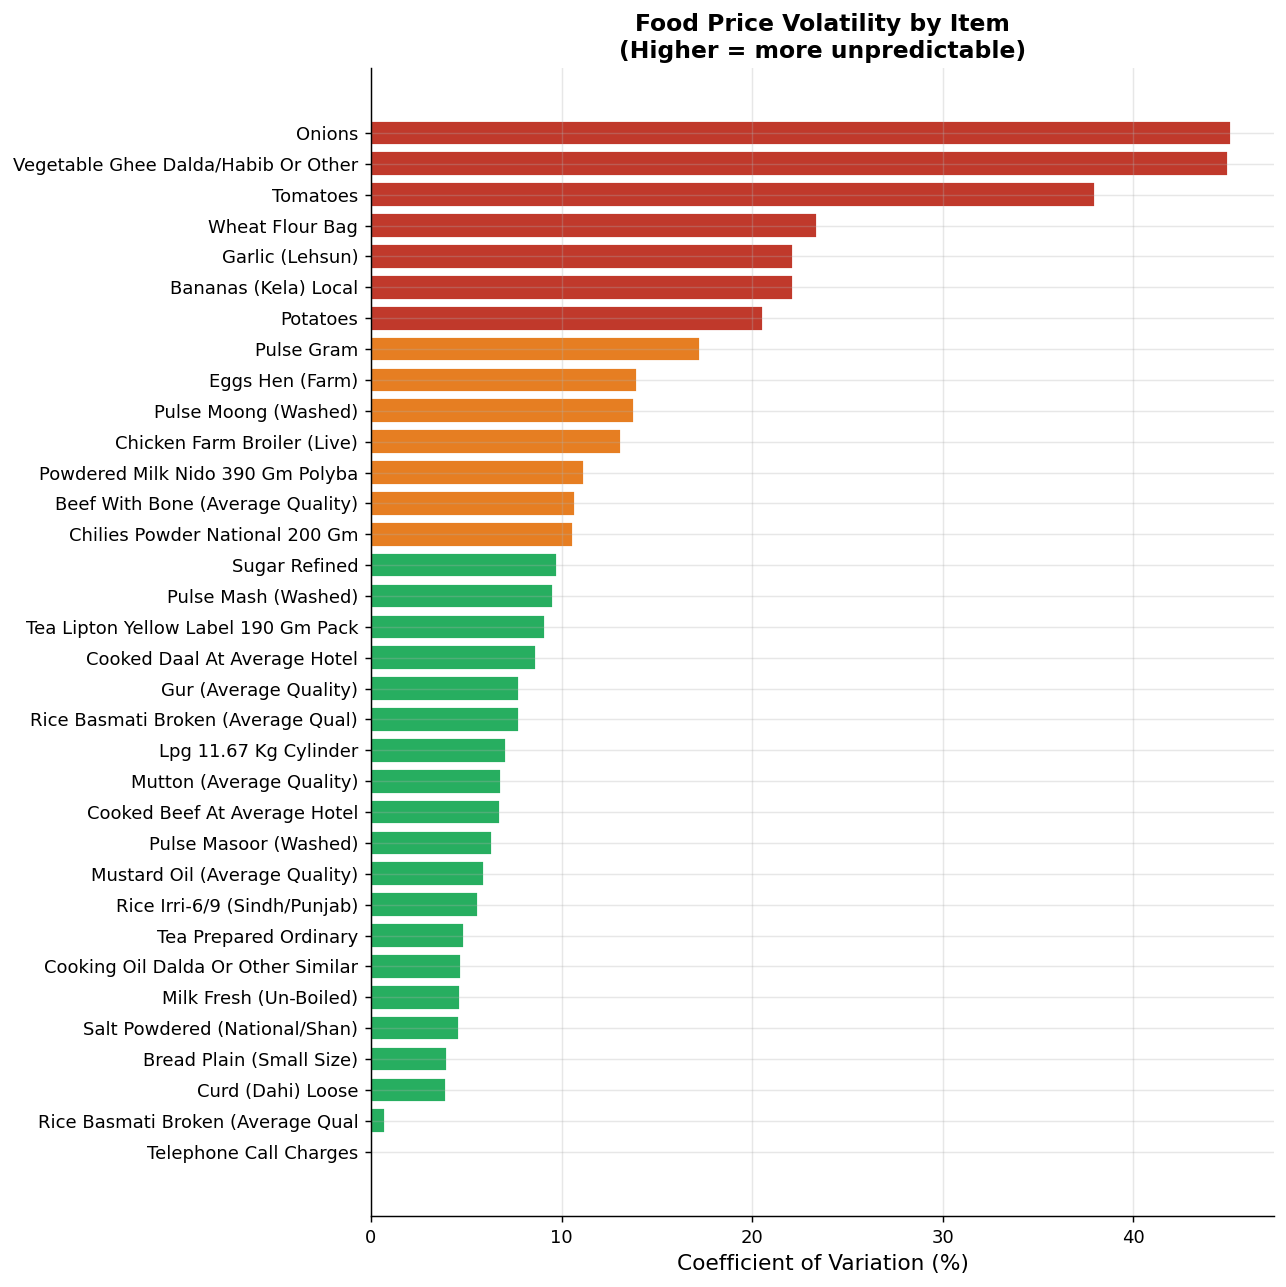

In [16]:
# ════════════════════════════════════════════════════════
# EDA 5: PRICE VOLATILITY (Coefficient of Variation)
# CV = std/mean × 100 — computed within each city, then averaged
# ════════════════════════════════════════════════════════

city_cv = spi_food.groupby(['City', 'Item'])['Avg_Price'].agg(
    lambda x: x.std() / x.mean() * 100 if x.mean() > 0 else 0
).reset_index()
city_cv.columns = ['City', 'Item', 'CV']
item_cv = city_cv.groupby('Item')['CV'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = [RED if v > 20 else ORANGE if v > 10 else GREEN for v in item_cv.values]
ax.barh(item_cv.index, item_cv.values, color=colors, edgecolor='white')
ax.set_xlabel('Coefficient of Variation (%)', fontsize=12)
ax.set_title('Food Price Volatility by Item\n(Higher = more unpredictable)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda5_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA 8 — Wheat Dependency Trend (NEW — Phase 3)

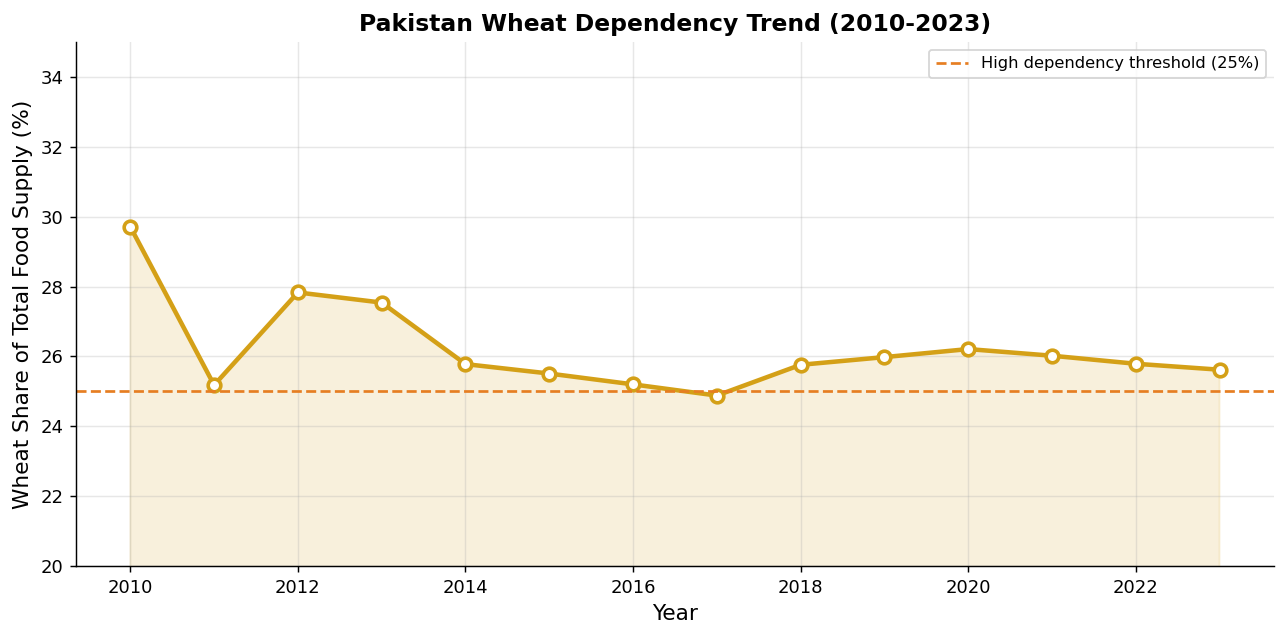

Wheat share range: 24.9% to 29.7%


In [17]:
# ════════════════════════════════════════════════════════
# EDA 8 (NEW): WHEAT DEPENDENCY TREND (2010-2023)
# Answers RQ4: Is Pakistan dangerously dependent on wheat?
# ════════════════════════════════════════════════════════

food_only = fao_clean[fao_clean['Element'] == 'Food supply quantity (kg/capita/yr)'].copy()
yr_cols = [c for c in food_only.columns if isinstance(c, (int, np.integer))]
if len(yr_cols) == 0:
    yr_cols = [c for c in food_only.columns if str(c).isdigit()]

total_by_year = food_only[yr_cols].sum(axis=0)
wheat_row = food_only[food_only['Item'] == 'Wheat and products']
wheat_by_year = wheat_row[yr_cols].iloc[0]
wheat_pct = (wheat_by_year / total_by_year * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
years = [int(y) for y in wheat_pct.index]
ax.plot(years, wheat_pct.values, color=GOLD, linewidth=2.5,
        marker='o', markersize=7, markerfacecolor='white',
        markeredgecolor=GOLD, markeredgewidth=2)
ax.fill_between(years, wheat_pct.values, alpha=0.15, color=GOLD)
ax.axhline(25, color=ORANGE, linewidth=1.5, linestyle='--',
           label='High dependency threshold (25%)')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Wheat Share of Total Food Supply (%)', fontsize=12)
ax.set_title('Pakistan Wheat Dependency Trend (2010-2023)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(20, 35)
plt.tight_layout()
plt.savefig('eda8_wheat_dependency.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Wheat share range: {wheat_pct.min():.1f}% to {wheat_pct.max():.1f}%")

## EDA 9 — Protein Adequacy vs WHO Thresholds (NEW — Phase 3)

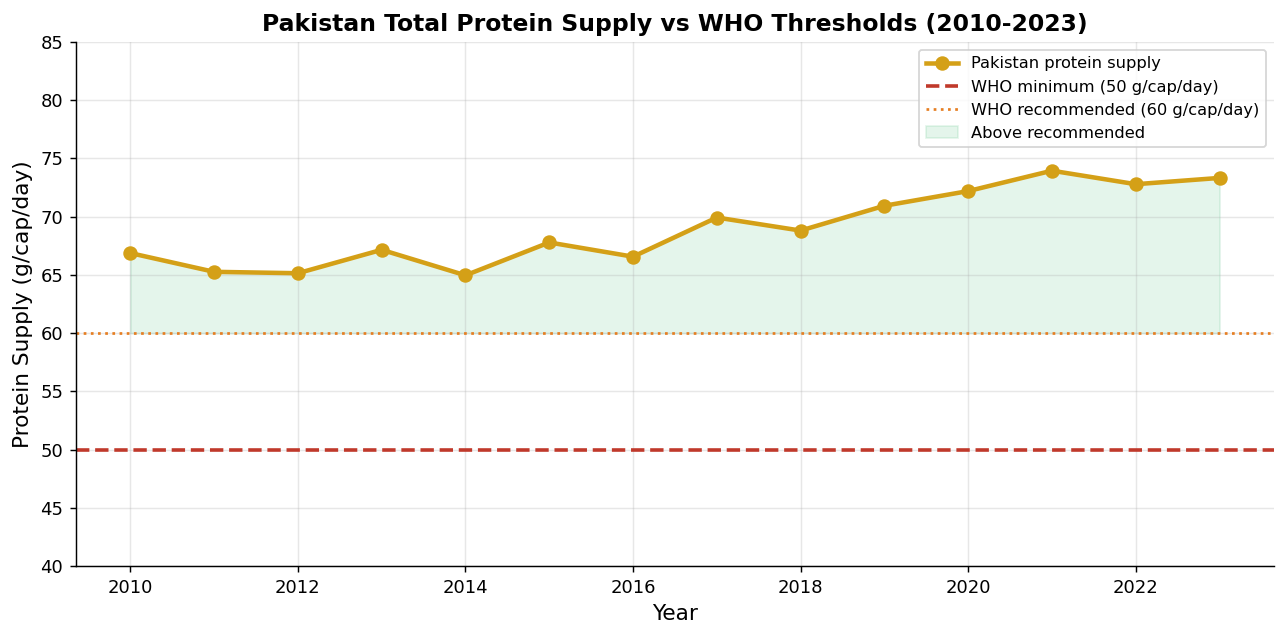

Protein 2022: 72.78 g/cap/day (WHO min = 50)


In [18]:
# ════════════════════════════════════════════════════════
# EDA 9 (NEW): PROTEIN ADEQUACY vs WHO STANDARD
# This analysis was incorrectly skipped in Phase 2 due to
# the FAO pivot bug. Protein data is correct in the fixed file.
# ════════════════════════════════════════════════════════

protein_rows = fao_clean[fao_clean['Element'] == 'Protein supply quantity (g/capita/day)'].copy()
total_protein = protein_rows[yr_cols].sum(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
years_p = [int(y) for y in total_protein.index]
ax.plot(years_p, total_protein.values, color=GOLD, linewidth=2.5,
        marker='o', markersize=7, label='Pakistan protein supply')
ax.axhline(50, color=RED, linewidth=2, linestyle='--', label='WHO minimum (50 g/cap/day)')
ax.axhline(60, color=ORANGE, linewidth=1.5, linestyle=':', label='WHO recommended (60 g/cap/day)')
ax.fill_between(years_p, 60, total_protein.values,
                where=[v >= 60 for v in total_protein.values],
                alpha=0.12, color=GREEN, label='Above recommended')
ax.set_ylim(40, 85)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Protein Supply (g/cap/day)', fontsize=12)
ax.set_title('Pakistan Total Protein Supply vs WHO Thresholds (2010-2023)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('eda9_protein.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Protein 2022: {total_protein.iloc[-2]:.2f} g/cap/day (WHO min = 50)")

## EDA 10 — Province-Level Price Comparison (NEW — Phase 3)

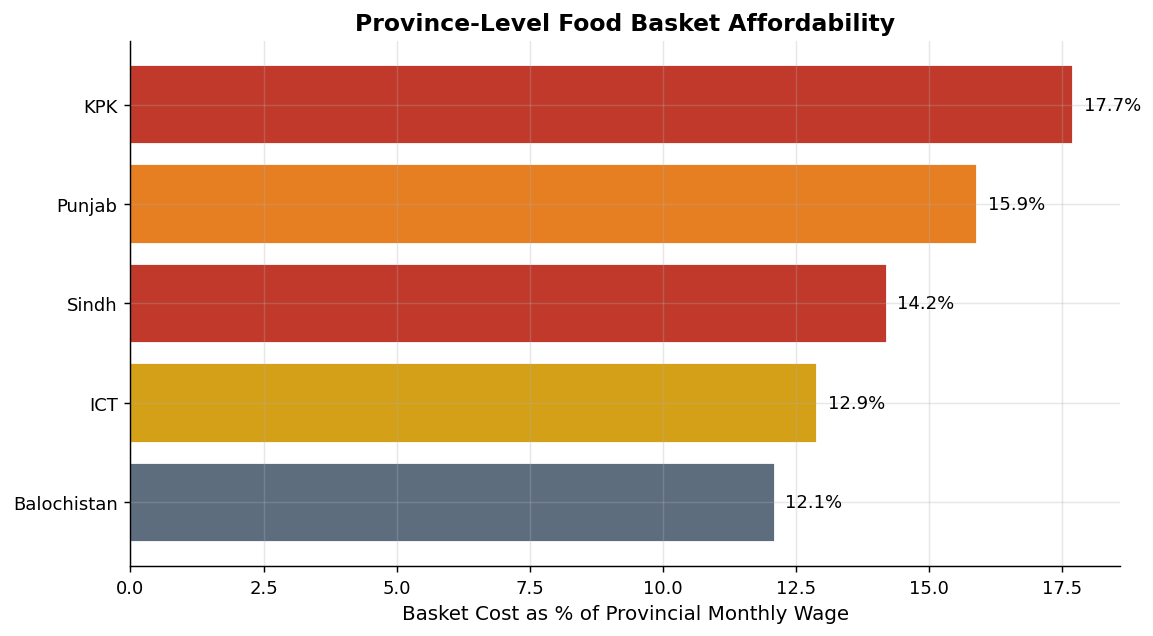


PHASE 2 EDA COMPLETE — 10 analyses produced


In [19]:
# ════════════════════════════════════════════════════════
# EDA 10 (NEW): PROVINCE-LEVEL COMPARISON
# ════════════════════════════════════════════════════════

basket_df = spi_food[spi_food['Item'].isin(BASKET_ITEMS)].copy()
prov_basket = basket_df.groupby('Province')['Avg_Price'].mean() * 10
prov_basket = prov_basket.reset_index()
prov_basket.columns = ['Province', 'Basket_Cost']
prov_basket['Wage'] = prov_basket['Province'].map(PROV_WAGES)
prov_basket['Affordability_Pct'] = (prov_basket['Basket_Cost'] / prov_basket['Wage'] * 100).round(1)
prov_basket = prov_basket.sort_values('Affordability_Pct', ascending=True)

colors_prov = {'ICT': GOLD, 'Punjab': ORANGE, 'Sindh': RED, 'KPK': RED, 'Balochistan': GREY}

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [colors_prov.get(p, GREY) for p in prov_basket['Province']]
bars = ax.barh(prov_basket['Province'], prov_basket['Affordability_Pct'],
               color=bar_colors, edgecolor='white')
for bar, val in zip(bars, prov_basket['Affordability_Pct']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Basket Cost as % of Provincial Monthly Wage', fontsize=11)
ax.set_title('Province-Level Food Basket Affordability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda10_province.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("PHASE 2 EDA COMPLETE — 10 analyses produced")
print("="*55)

---
# PHASE 3 — STATISTICAL MODELLING & MACHINE LEARNING

Three algorithms: Linear Regression (in-class), Naive Bayes (in-class), K-Means (outside-class).

## Feature Engineering

In [20]:
# ════════════════════════════════════════════════════════
# PHASE 3: FEATURE ENGINEERING — City-Level Feature Matrix
# ════════════════════════════════════════════════════════

city_df = spi_food.groupby('City').agg(
    Avg_Price        = ('Avg_Price', 'mean'),
    Price_Volatility = ('Avg_Price', 'std'),
    Province         = ('Province', 'first'),
).reset_index()
city_df['Wage'] = city_df['Province'].map(PROV_WAGES)

basket_city = spi_food[spi_food['Item'].isin(BASKET_ITEMS)].groupby('City')['Avg_Price'].mean() * 10
city_df = city_df.merge(basket_city.rename('Basket_Cost'), on='City')
city_df['Affordability_Pct'] = (city_df['Basket_Cost'] / city_df['Wage'] * 100).round(2)

for item_name, col_name in [
    ('Wheat Flour Bag', 'Wheat_CV'),
    ('Tomatoes', 'Tomato_CV'),
    ('Milk Fresh (Un-Boiled)', 'Milk_CV'),
]:
    sub = spi_food[spi_food['Item'] == item_name].groupby('City')['Avg_Price'].apply(
        lambda x: x.std() / x.mean() * 100)
    city_df = city_df.merge(sub.rename(col_name), on='City', how='left')

print("City-level feature matrix:")
print(city_df[['City', 'Province', 'Avg_Price', 'Basket_Cost',
               'Affordability_Pct', 'Wage']].to_string())

City-level feature matrix:
          City     Province   Avg_Price  Basket_Cost  Affordability_Pct   Wage
0   Bahawalpur       Punjab  592.957389  6829.826929              15.88  43000
1        Bannu          KPK  459.770625  5358.499524              16.75  32000
2   Faisalabad       Punjab  598.681954  6539.769214              15.21  43000
3   Gujranwala       Punjab  613.715518  7163.713862              16.66  43000
4    Hyderabad        Sindh  608.450564  6829.079548              14.53  47000
5    Islamabad          ICT  640.078536  6861.082143              12.95  53000
6      Karachi        Sindh  557.469480  6436.293857              13.69  47000
7       Lahore       Punjab  609.093437  7034.339137              16.36  43000
8      Larkana        Sindh  594.217873  6639.676357              14.13  47000
9       Multan       Punjab  610.864180  6825.204369              15.87  43000
10    Peshawar          KPK  539.912110  5988.111369              18.71  32000
11      Quetta  Balochist

## Model 1 — Linear Regression

MODEL 1: LINEAR REGRESSION
  R² = 0.9604  |  MAE = PKR 151.4  |  RMSE = PKR 179.9
  Coefficients: {'Avg_Price': np.float64(9.0485), 'Price_Volatility': np.float64(1.8664), 'Wage': np.float64(-0.0008)}
  Intercept: -82.36


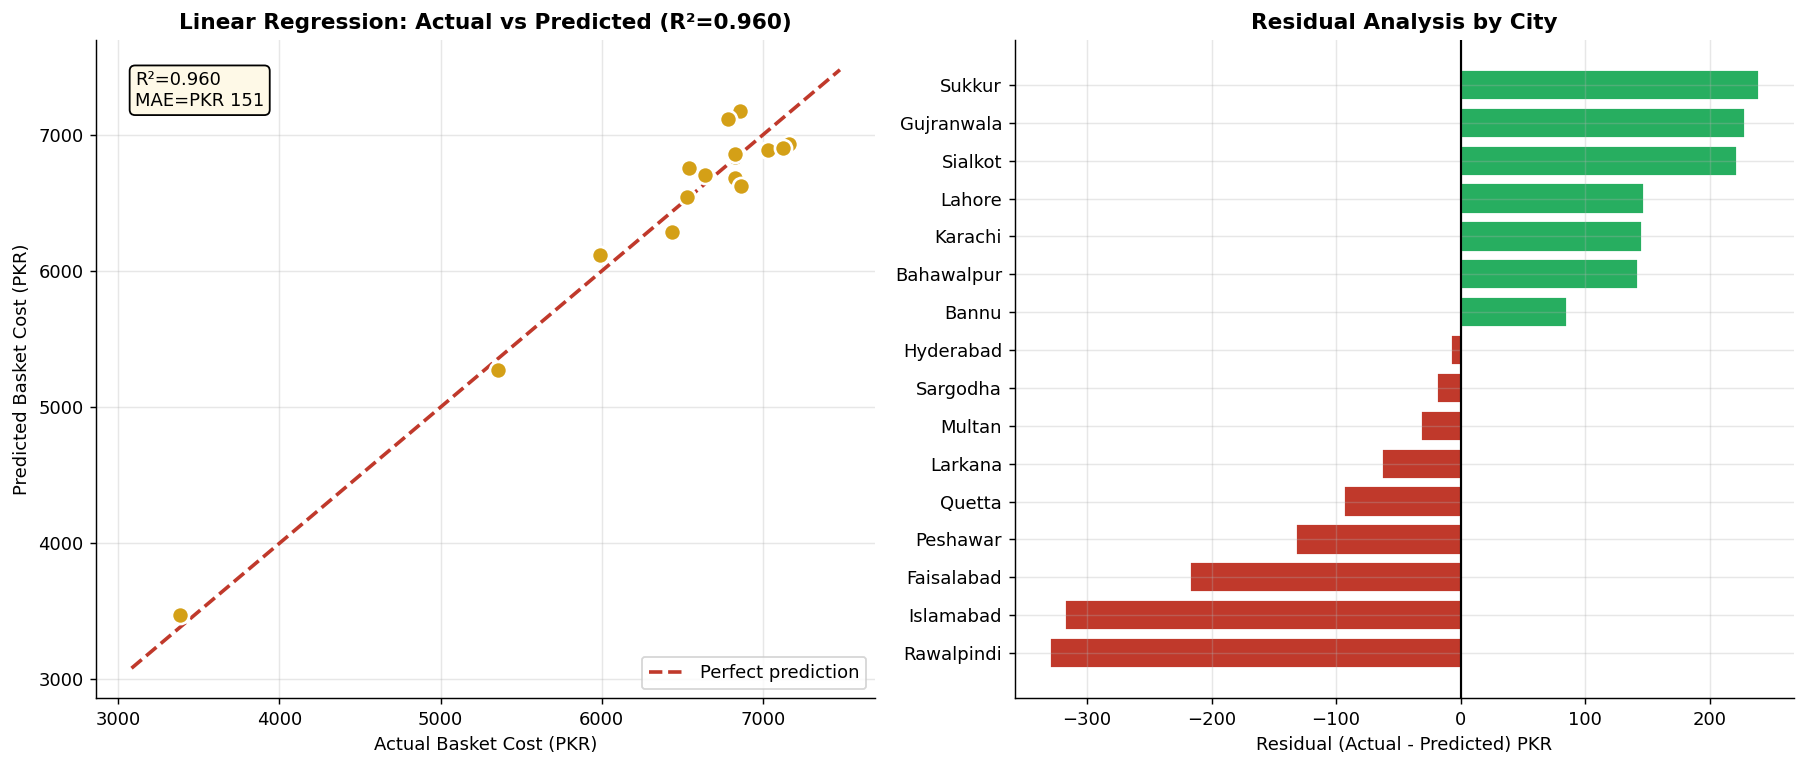

In [21]:
# ════════════════════════════════════════════════════════
# MODEL 1: LINEAR REGRESSION
# Target: Basket_Cost | Features: Avg_Price, Volatility, Wage
# ════════════════════════════════════════════════════════

FEATURES_LR = ['Avg_Price', 'Price_Volatility', 'Wage']
X_lr = city_df[FEATURES_LR].values
y_lr = city_df['Basket_Cost'].values

lr = LinearRegression()
lr.fit(X_lr, y_lr)
y_pred_lr = lr.predict(X_lr)

r2   = r2_score(y_lr, y_pred_lr)
mae  = mean_absolute_error(y_lr, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_lr, y_pred_lr))

city_df['LR_Predicted'] = y_pred_lr.round(1)
city_df['LR_Residual']  = (y_lr - y_pred_lr).round(1)

print("MODEL 1: LINEAR REGRESSION")
print(f"  R² = {r2:.4f}  |  MAE = PKR {mae:.1f}  |  RMSE = PKR {rmse:.1f}")
print(f"  Coefficients: {dict(zip(FEATURES_LR, lr.coef_.round(4)))}")
print(f"  Intercept: {lr.intercept_:.2f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(y_lr, y_pred_lr, color=GOLD, s=90, edgecolors='white', linewidth=1.5, zorder=5)
lim = [min(y_lr.min(), y_pred_lr.min())-300, max(y_lr.max(), y_pred_lr.max())+300]
ax1.plot(lim, lim, color=RED, linewidth=2, linestyle='--', label='Perfect prediction')
ax1.set_xlabel('Actual Basket Cost (PKR)')
ax1.set_ylabel('Predicted Basket Cost (PKR)')
ax1.set_title(f'Linear Regression: Actual vs Predicted (R²={r2:.3f})', fontweight='bold')
ax1.legend()
ax1.text(0.05, 0.90, f'R²={r2:.3f}\nMAE=PKR {mae:.0f}', transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#FEF9E7'))

residual_order = city_df.sort_values('LR_Residual')
bar_colors = [RED if r < 0 else GREEN for r in residual_order['LR_Residual']]
ax2.barh(residual_order['City'], residual_order['LR_Residual'], color=bar_colors, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1.2)
ax2.set_xlabel('Residual (Actual - Predicted) PKR')
ax2.set_title('Residual Analysis by City', fontweight='bold')
plt.tight_layout()
plt.savefig('model1_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 2 — Gaussian Naive Bayes

MODEL 2: GAUSSIAN NAIVE BAYES
  LOO-CV Accuracy: 0.688 +/- 0.464
  Training Accuracy: 0.875
              precision    recall  f1-score   support

  Low Stress       1.00      0.75      0.86         8
 High Stress       0.80      1.00      0.89         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16



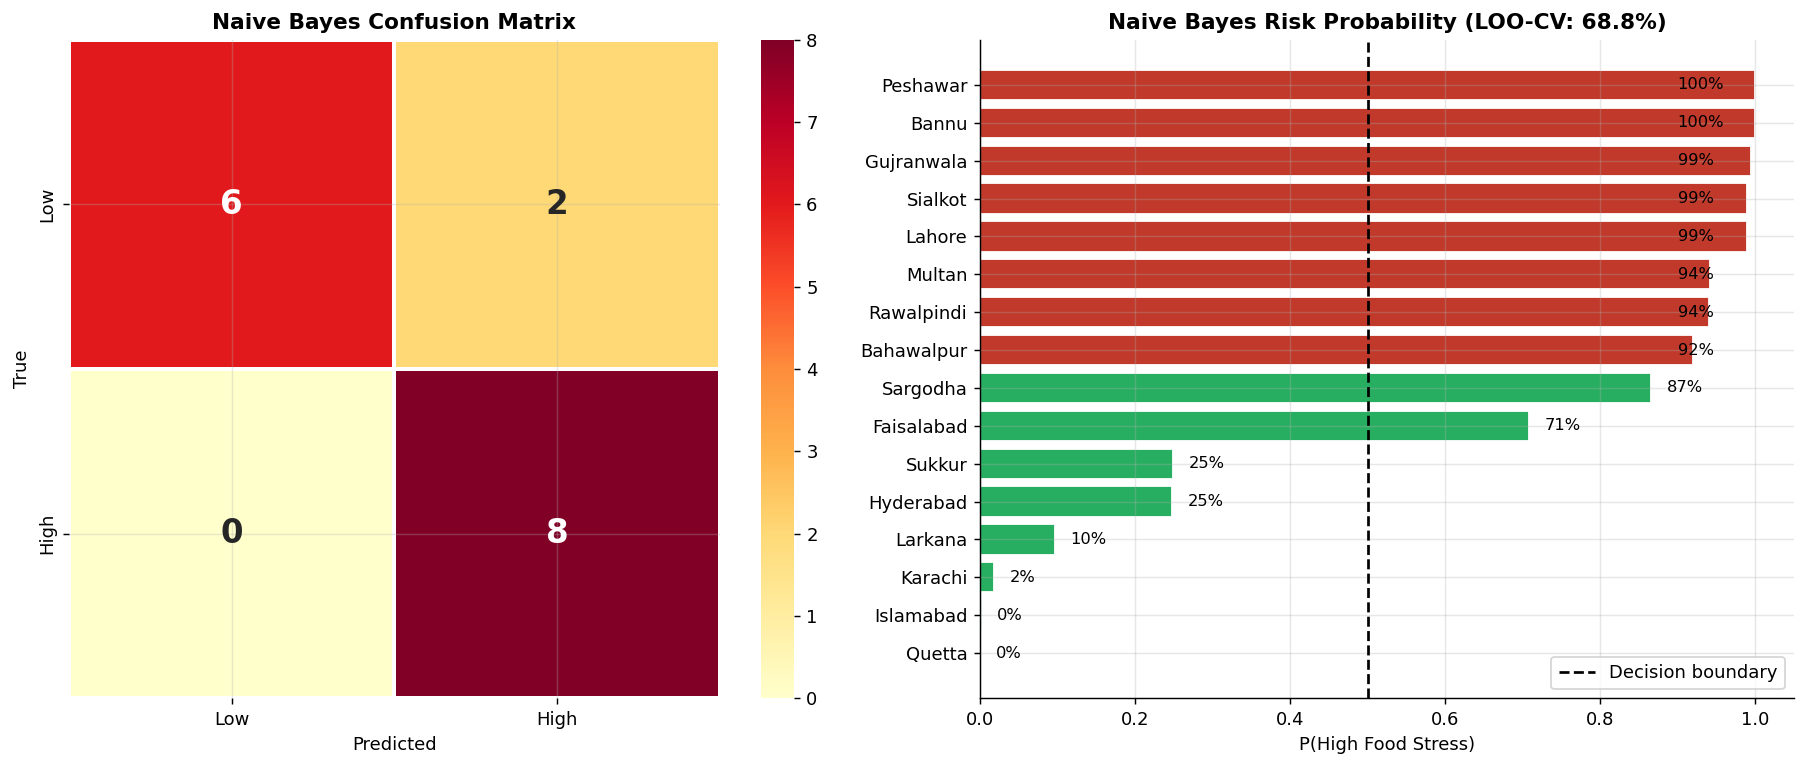

In [22]:
# ════════════════════════════════════════════════════════
# MODEL 2: GAUSSIAN NAIVE BAYES
# Task: Classify city as High/Low Food Stress
# ════════════════════════════════════════════════════════

MEDIAN_AFF = city_df['Affordability_Pct'].median()
city_df['Food_Stress'] = (city_df['Affordability_Pct'] > MEDIAN_AFF).astype(int)
city_df['Food_Stress_Label'] = city_df['Food_Stress'].map({0:'Low Stress', 1:'High Stress'})

FEATURES_NB = ['Avg_Price', 'Price_Volatility', 'Affordability_Pct',
               'Wheat_CV', 'Tomato_CV', 'Milk_CV']
X_nb = city_df[FEATURES_NB].fillna(0).values
y_nb = city_df['Food_Stress'].values

nb = GaussianNB()
loo = LeaveOneOut()
loo_scores = cross_val_score(nb, X_nb, y_nb, cv=loo, scoring='accuracy')
nb.fit(X_nb, y_nb)
y_pred_nb = nb.predict(X_nb)
proba_nb  = nb.predict_proba(X_nb)

city_df['NB_Pred_Label'] = np.where(y_pred_nb == 1, 'High Stress', 'Low Stress')
city_df['NB_P_High']     = proba_nb[:, 1].round(3)

print("MODEL 2: GAUSSIAN NAIVE BAYES")
print(f"  LOO-CV Accuracy: {loo_scores.mean():.3f} +/- {loo_scores.std():.3f}")
print(f"  Training Accuracy: {accuracy_score(y_nb, y_pred_nb):.3f}")
print(classification_report(y_nb, y_pred_nb, target_names=['Low Stress', 'High Stress']))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
cm = confusion_matrix(y_nb, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'],
            linewidths=2, linecolor='white', ax=ax1, annot_kws={'size': 18, 'weight': 'bold'})
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.set_title('Naive Bayes Confusion Matrix', fontweight='bold')

city_sorted = city_df.sort_values('NB_P_High')
colors_prob = [RED if s == 1 else GREEN for s in city_sorted['Food_Stress']]
ax2.barh(city_sorted['City'], city_sorted['NB_P_High'], color=colors_prob, edgecolor='white')
ax2.axvline(0.5, color='black', linewidth=1.5, linestyle='--', label='Decision boundary')
for bar, val in zip(ax2.patches, city_sorted['NB_P_High']):
    ax2.text(min(val+0.02, 0.90), bar.get_y()+bar.get_height()/2,
             f'{val:.0%}', va='center', fontsize=9)
ax2.set_xlabel('P(High Food Stress)')
ax2.set_title(f'Naive Bayes Risk Probability (LOO-CV: {loo_scores.mean():.1%})', fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.savefig('model2_nb.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 3 — K-Means Clustering (Outside-Class)

In [26]:
# ════════════════════════════════════════════════════════
# MODEL 3: K-MEANS CLUSTERING
# Citation: MacQueen (1967), UC Press
# ════════════════════════════════════════════════════════
FEATURES_KM = ['Avg_Price', 'Price_Volatility', 'Affordability_Pct', 'Wage']
X_km = city_df[FEATURES_KM].values
scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X_km)

sil_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    sil_scores.append((k, sil))
    print(f"  K={k}: Silhouette={sil:.3f}")

best_k = max(sil_scores, key=lambda x: x[1])[0]
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
city_df['Cluster'] = km_final.fit_predict(X_scaled)

cluster_labels = {0: 'Mainstream Urban (Moderate Stress)',
                  1: 'Low-Wage Periphery (Extreme Risk)'}
city_df['Cluster_Label'] = city_df['Cluster'].map(cluster_labels)

sil_final = silhouette_score(X_scaled, km_final.labels_)
print(f"\nBest K = {best_k}, Silhouette = {sil_final:.3f}")

# FIX: sort the full dataframe first, then select display columns
print(city_df.sort_values('Cluster')[['City', 'Province', 'Cluster', 'Cluster_Label']].to_string())

  K=2: Silhouette=0.606
  K=3: Silhouette=0.587
  K=4: Silhouette=0.465
  K=5: Silhouette=0.449
  K=6: Silhouette=0.400

Best K = 2, Silhouette = 0.606
          City     Province  Cluster                       Cluster_Label
0   Bahawalpur       Punjab        0  Mainstream Urban (Moderate Stress)
2   Faisalabad       Punjab        0  Mainstream Urban (Moderate Stress)
3   Gujranwala       Punjab        0  Mainstream Urban (Moderate Stress)
4    Hyderabad        Sindh        0  Mainstream Urban (Moderate Stress)
6      Karachi        Sindh        0  Mainstream Urban (Moderate Stress)
5    Islamabad          ICT        0  Mainstream Urban (Moderate Stress)
7       Lahore       Punjab        0  Mainstream Urban (Moderate Stress)
8      Larkana        Sindh        0  Mainstream Urban (Moderate Stress)
14     Sialkot       Punjab        0  Mainstream Urban (Moderate Stress)
9       Multan       Punjab        0  Mainstream Urban (Moderate Stress)
13    Sargodha       Punjab        0  Mainstr

## Export ML Results for Power BI

In [28]:
# ════════════════════════════════════════════════════════
# EXPORT ML RESULTS FOR POWER BI DASHBOARD
# ════════════════════════════════════════════════════════

ml_export = city_df[['City', 'Province', 'Avg_Price', 'Price_Volatility',
                      'Basket_Cost', 'Wage', 'Affordability_Pct',
                      'Food_Stress', 'Food_Stress_Label',
                      'LR_Predicted', 'LR_Residual',
                      'NB_P_High', 'NB_Pred_Label',
                      'Cluster', 'Cluster_Label']].copy()
ml_export.to_csv('city_ml_results.csv', index=False)

print("="*55)
print("PHASE 3 COMPLETE — All models trained, results exported")
print("="*55)
print("\nFinal Summary:")
print(f"  Linear Regression R² = {r2:.4f}")
print(f"  Naive Bayes LOO-CV   = {loo_scores.mean():.3f}")
print(f"  K-Means Silhouette   = {sil_final:.3f}")
print(f"\nHighest risk cities: Peshawar (P=1.00), Bannu (P=1.00)")
print(f"Lowest risk cities:  Islamabad (P=0.00), Quetta (P=0.00)")
print(f"\nFiles saved:")
print("  city_ml_results.csv (for Power BI)")
print("  All EDA charts (PNG)")
print("  All model charts (PNG)")

PHASE 3 COMPLETE — All models trained, results exported

Final Summary:
  Linear Regression R² = 0.9604
  Naive Bayes LOO-CV   = 0.688
  K-Means Silhouette   = 0.606

Highest risk cities: Peshawar (P=1.00), Bannu (P=1.00)
Lowest risk cities:  Islamabad (P=0.00), Quetta (P=0.00)

Files saved:
  city_ml_results.csv (for Power BI)
  All EDA charts (PNG)
  All model charts (PNG)
